# Electricity Load Consumption Forecasting

###  **Abstract**

> This project analyzes $\color{blue}{\textbf{electricity consumption data}}$ using **time series techniques**.  
>  The dataset consists of **hourly   electricity consumption                  measurements** aggregated into a **monthly time series**.  
>  Several modeling approaches are explored, including:
>  - <span style="color:#"><b>Linear trend</b></span> with seasonal components  
>  - <span style="color:#"><b>Differencing-based methods</b></span>  
>  - <span style="color:#"><b>Filtering techniques</b></span>  
>
>  Each approach is evaluated through **model fitting** and **diagnostic analysis**.  
>  Forecasts are generated and compared to assess **model performance**.  
> The results highlight the <b>strengths</b> and <b>limitations</b> of each method in capturing **trend** and **seasonality**.



## 1. Introduction
  
>  Understanding and forecasting electricity demand is essential for:
>  - <b>Production planning</b>  
>  - <b>Resource optimization</b>  
>  - <b>System stability</b>  

> The data originally consists of **daily observations** with **hourly measurements**.  
> After preprocessing, it is transformed into a <span style="color: "><b>time series</b></span> suitable for analysis.

> Electricity consumption typically exhibits:
> -  $\color{blue}{\textbf{Trend}}$
> - $\color{blue}{\textbf{Seasonality}}$ 

> The objective of this project is to analyze the **structure of the data** and develop models capable of accurately **forecasting future consumption**.



##   2. Model Specification

>In this project, <b>three different modeling strategies</b> are considered.



###  2.1 Linear Trend + Seasonal Model

 The observed series is decomposed as:

$$
Y_t = u_t + X_t
$$

where the  $\color{blue}{\textbf{deterministic component}}$ is defined by:

$$
u_t = \beta_0 + \beta_1 t + \beta_2 \cos\left(\frac{2\pi t}{m}\right) + \beta_3 \sin\left(\frac{2\pi t}{m}\right)
$$

 and the   $\color{blue}{\textbf{stochastic component}}$  follows an AR(1):

$$
X_t = \phi X_{t-1} + \varepsilon_t
$$

>  This model explicitly captures:
> - <b>Trend</b> via $\beta_1 t$  
> - <b>Seasonality</b> via sine and cosine terms  
> - <b>Temporal dependence</b> via the AR(1) structure  



###  2.2 Differencing-Based Approach

 To achieve stationarity, we apply both regular and seasonal differencing operators:

$$
\nabla^{1} \nabla^{12} Y_t = \varepsilon_t
$$

> where:
> - $\nabla^{1} = (1 - B)$ represents the <b>first-order difference</b>  removes Trend
> - $\nabla^{12} = (1 - B^{12})$ represents the <b>seasonal difference</b>  removes Seasonality


> resulting in a <b>stationary time series</b> suitable for modeling.




###  2.3 Filtering Approach

 The series is decomposed into:

$$
Y_t = T_t + X_t
$$

 where the $\color{blue}{\textbf{trend component}}$   is estimated using a moving average filter:

$$
T_t = \frac{1}{6} \left( Y_{t-1} + Y_{t-2} + Y_{t-3} + Y_{t-4} + Y_{t-5} + Y_{t-6} \right)
$$

 and the $\color{blue}{\textbf{noise component}}$  is modeled as MA(4):

$$
X_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \theta_3 \varepsilon_{t-3} + \theta_4 \varepsilon_{t-4}
$$

>  This approach:
> - Extracts <b>trend</b> through smoothing  
> - Models residual dynamics using a <b>moving average process (MA)</b>  
> - Helps isolate the <b>underlying signal</b> from noise  


## Analysing the data

In [2]:
library(tseries)
library(TSA)
library(forecast)

In [3]:
# Load the monthly data
df <- read.csv("data.csv")
df$YearMonth <- as.Date(df$YearMonth)
df <- ts(df$Load, start = c(2014, 1), frequency = 12)
y_original <- df

[1] 144

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,3877.000,3925.083,3959.417,3834.250,4001.250,4001.000,3957.333,3909.667,3919.083,3926.917,4024.750,4017.500
2015,4283.250,4300.083,4227.417,4326.083,4221.750,4307.333,4291.750,4296.417,4245.250,4187.750,4251.917,4297.583
2016,4454.917,4449.333,4431.833,4459.833,4442.417,4508.417,4478.000,4545.083,4571.000,4467.417,4468.833,4488.500
2017,4785.500,4818.083,4761.917,4764.917,4722.250,4756.833,4776.500,4785.750,4777.250,4778.667,4747.833,4800.250


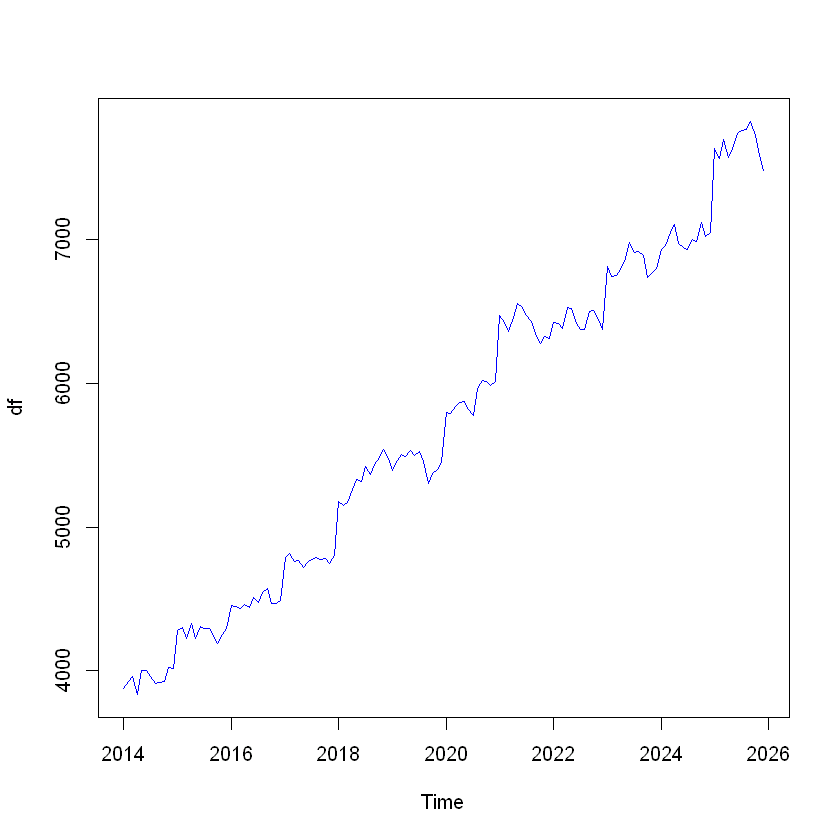

In [4]:
# to test correlation between residual later
length(df)
head(df,n = 48)
plot(df, col="blue")

>  - It is evident that the variance is not stable over time, indicating a need for variance stabilization. In particular, larger fluctuations are observed in the more recent period (around 2025) compared to earlier years (around 2014).
>  - Additionally, the series exhibits a clear upward linear trend, along with a seasonal pattern that is likely annual in nature (to be determined).

## Regularize the variance

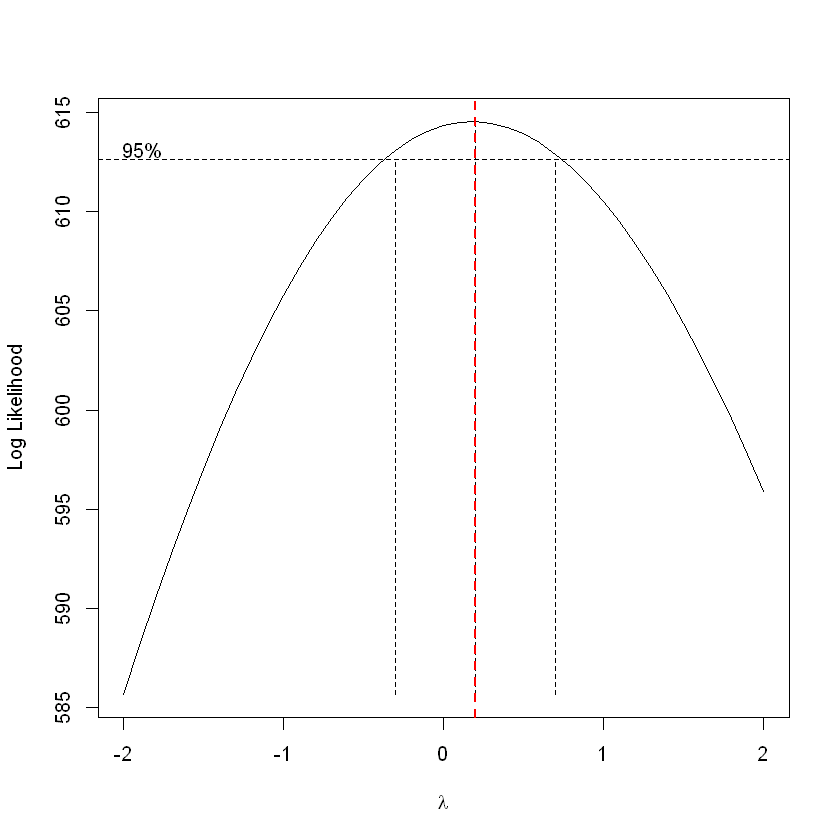

In [71]:
# Box-Cox analysis for AR process
BoxCox.ar(df)
abline(v=0.2, col="red", lty=2, lwd=2)

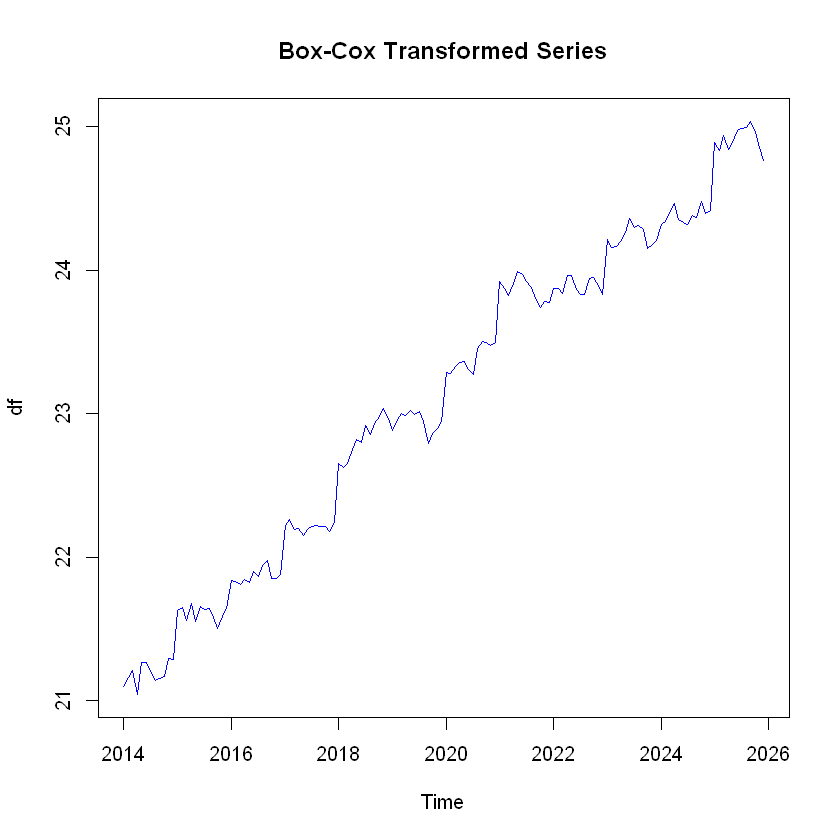

In [72]:
# lmabda is 0.2
df <- BoxCox(df, lambda = 0.2)
plot(df, col="blue", main="Box-Cox Transformed Series")

> - After applying the Box-Cox transformation, the variance appears more stable over time compared to the original series. This suggests that the transformation successfully reduced heteroscedasticity.

## Mode Specification & Diagnostics

### 1. Deterministic part

- Since I have some doubt in the period of seasonality let try just to fit linear part and see


Call:
lm(formula = df ~ time(df))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.32141 -0.12474  0.00246  0.11618  0.46871 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -6.395e+02  8.126e+00  -78.70   <2e-16 ***
time(df)     3.280e-01  4.023e-03   81.54   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1672 on 142 degrees of freedom
Multiple R-squared:  0.9791,	Adjusted R-squared:  0.9789 
F-statistic:  6649 on 1 and 142 DF,  p-value: < 2.2e-16


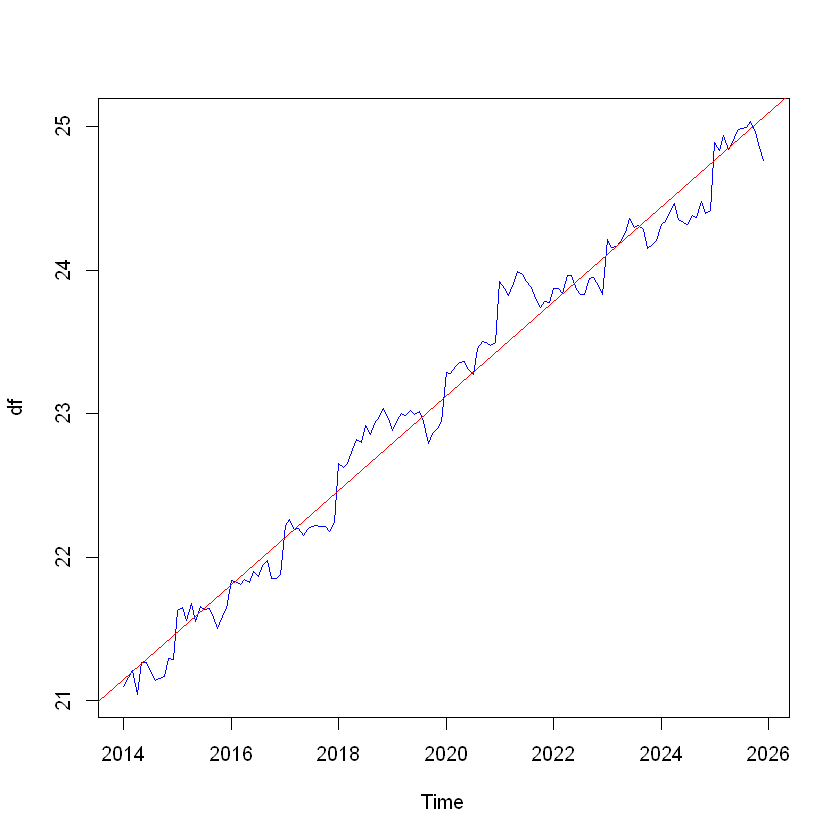

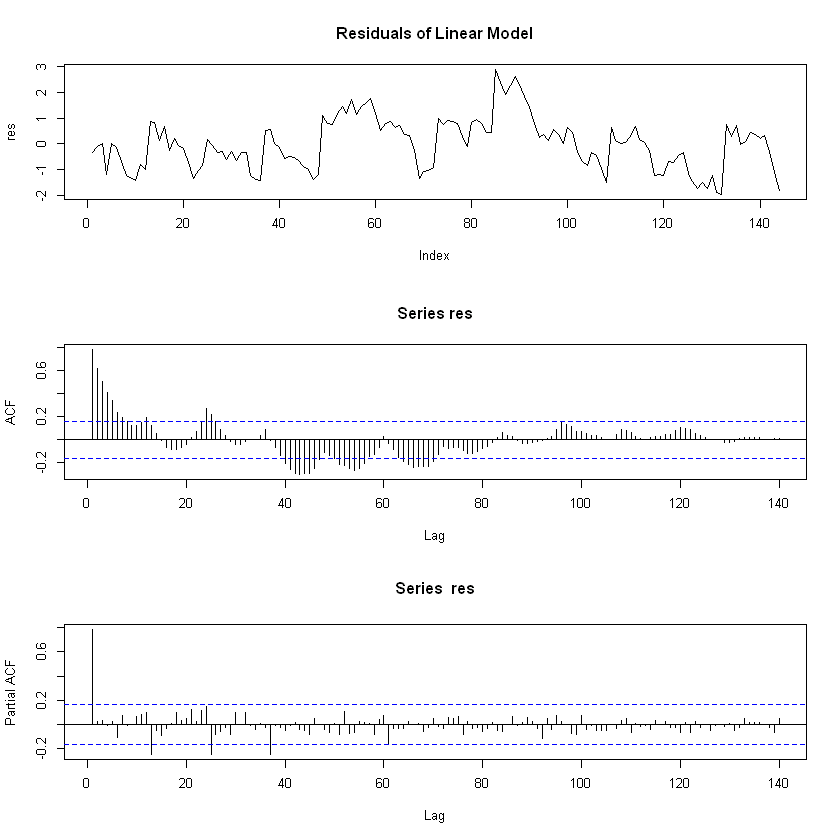

In [73]:
linearModel = lm(df~time(df))
summary(linearModel)

plot(df, col="blue",)
abline(linearModel, col="red")


res <- rstudent(linearModel)
par(mfrow=c(3,1))
plot(res, type='l', main="Residuals of Linear Model")
acf(res,lag.max=140)
pacf(res, lag.max=140)
par(mfrow=c(1,1))

> - From the plot of the residuals (`res`), there is no clear trend, and the series appears to fluctuate around a constant mean. However, the variance doesn't seem to be constant, there is still some indication of a seasonal pattern as we noticed and now it is confirmed, suggesting that the residuals are not purely random.
> - From the ACF and PACF of `res`, there is evidence of a seasonal structure, with a noticeable pattern consistent with a period of approximately `12`. This suggests that some seasonal dependence may still remain in the residuals.


Call:
lm(formula = df ~ t + cos(2 * pi * t/m) + sin(2 * pi * t/m))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.28888 -0.11163 -0.00741  0.08525  0.46480 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)       21.1211597  0.0261624 807.309  < 2e-16 ***
t                  0.0274324  0.0003132  87.581  < 2e-16 ***
cos(2 * pi * t/m) -0.0421333  0.0183761  -2.293   0.0233 *  
sin(2 * pi * t/m)  0.0783777  0.0184105   4.257 3.77e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1559 on 140 degrees of freedom
Multiple R-squared:  0.9821,	Adjusted R-squared:  0.9817 
F-statistic:  2558 on 3 and 140 DF,  p-value: < 2.2e-16


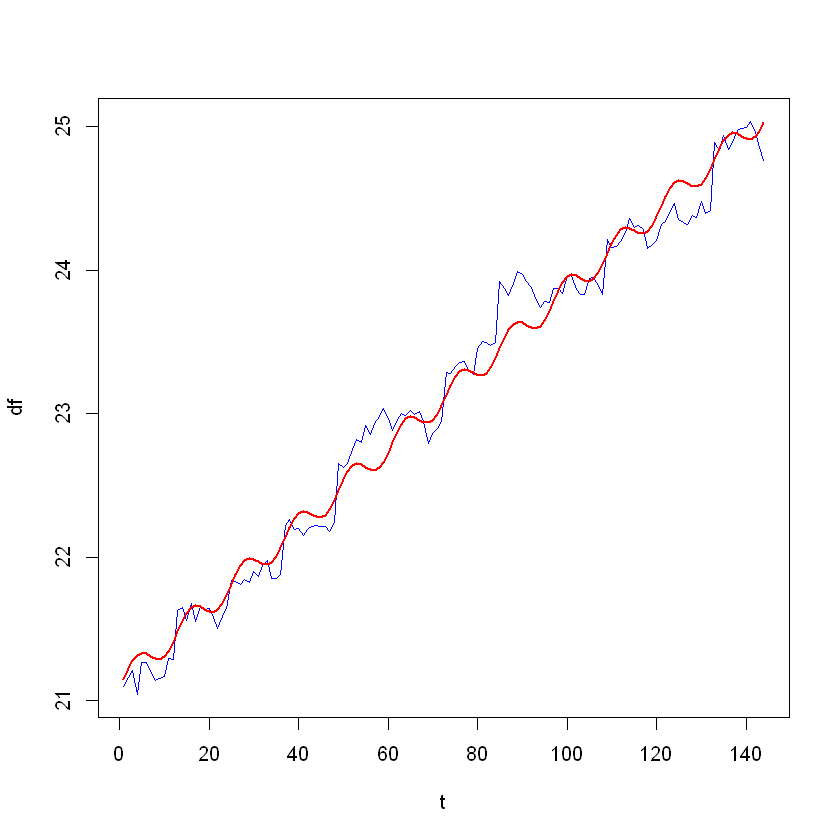

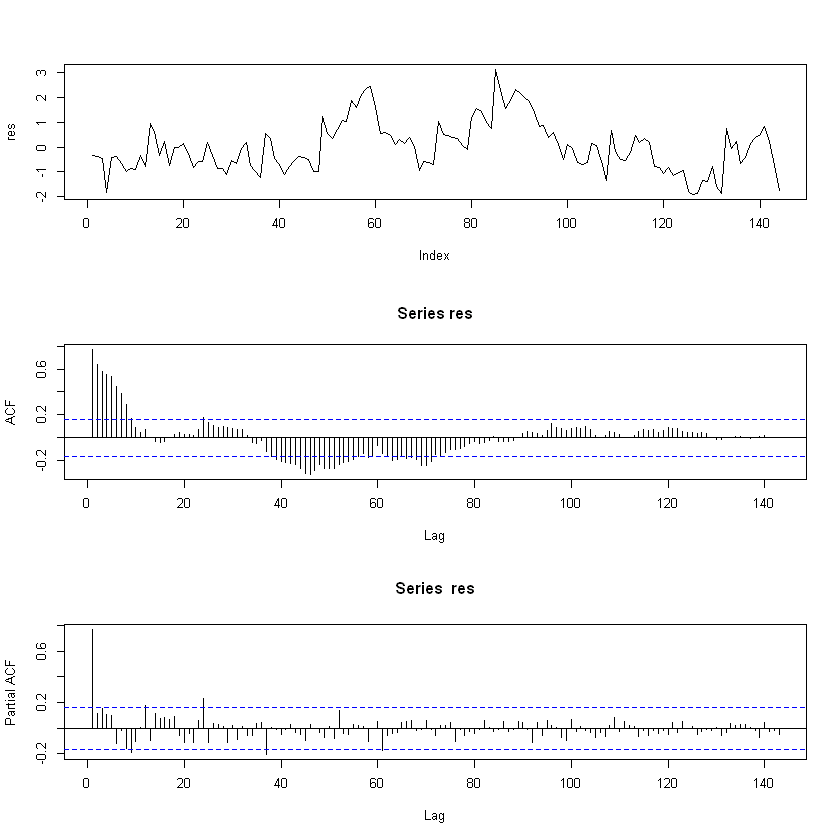

In [ ]:
# Seasonal period modeling
m <- 12
t <- 1:length(df)

# Fit one model: trend + seasonality (1 Harmonic)
full_model <- lm(df ~ t + cos(2 * pi * t / m) + sin(2 * pi * t / m))
summary(full_model)

plot(t, df, type="l", col="blue")
lines(t, fitted(full_model), col="red", lwd=2)

res <- rstudent(full_model)

par(mfrow=c(3,1))
plot(res, type='l')
acf(res, lag.max=144)
pacf(res, lag.max=144)
par(mfrow=c(1,1))

>   - After removing the linear and seasonal components as we can see that from 1st plot, we analyze the residual process \( X_t \).
>   - From the autocorrelation analysis, the PACF shows a significant spike at lag 1 and then becomes insignificant afterward, while the ACF decreases gradually. This suggests that the process may follow an `AR(1)` structure.
>   - As a result, there is evidence that the residual series is not white noise, since a clear autocorrelation structure is still present.

Series: res 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
         ar1     mean
      0.7782  -0.0472
s.e.  0.0524   0.2337

sigma^2 = 0.4101:  log likelihood = -139.61
AIC=285.22   AICc=285.39   BIC=294.12

Training set error measures:
                      ME      RMSE       MAE       MPE    MAPE      MASE
Training set 0.002207888 0.6359266 0.4572719 -1202.569 1346.75 0.9671301
                    ACF1
Training set -0.07978846

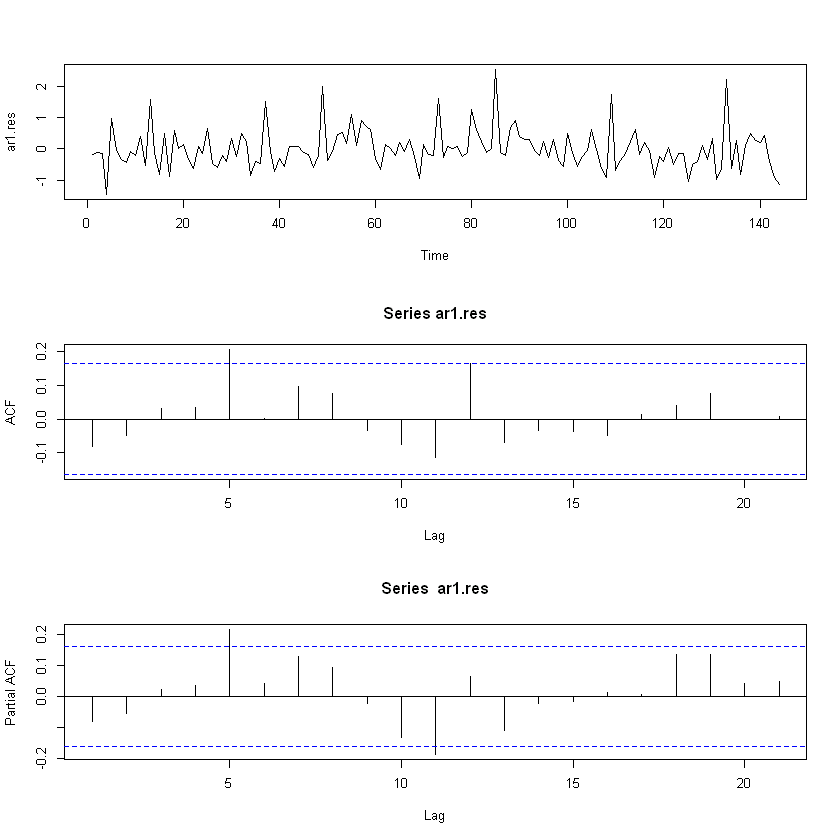

In [80]:
ar1 = Arima(res, order=c(1,0,0))
summary(ar1)

ar1.res = residuals(ar1)

par(mfrow=c(3,1))
plot(ar1.res, type='l')
acf(ar1.res)
pacf(ar1.res)
par(mfrow=c(1,1))

> - After fitting an `AR(1)` model, the residuals appear to behave more like white noise based on the time plot, as they fluctuate randomly around a constant mean close to zero.
> - The model selection criteria, with `AIC = 285.22` and `BIC = 294.12`, indicate a reasonably good fit compared to alternative specifications (that I have tried before). 
> - Additionally, the residual plot indicates a stable mean around zero, which supports the assumption of stationarity in the error terms.
> - From the ACF and PACF plots, most of the spikes lie within the confidence bounds (`±2/√n`), which suggests the absence of significant autocorrelation. However, this should be formally validated using a Ljung–Box test.

$pvalue
[1] 0.842

$observed.runs
[1] 73

$expected.runs
[1] 71.31944

$n1
[1] 83

$n2
[1] 61

$k
[1] 0

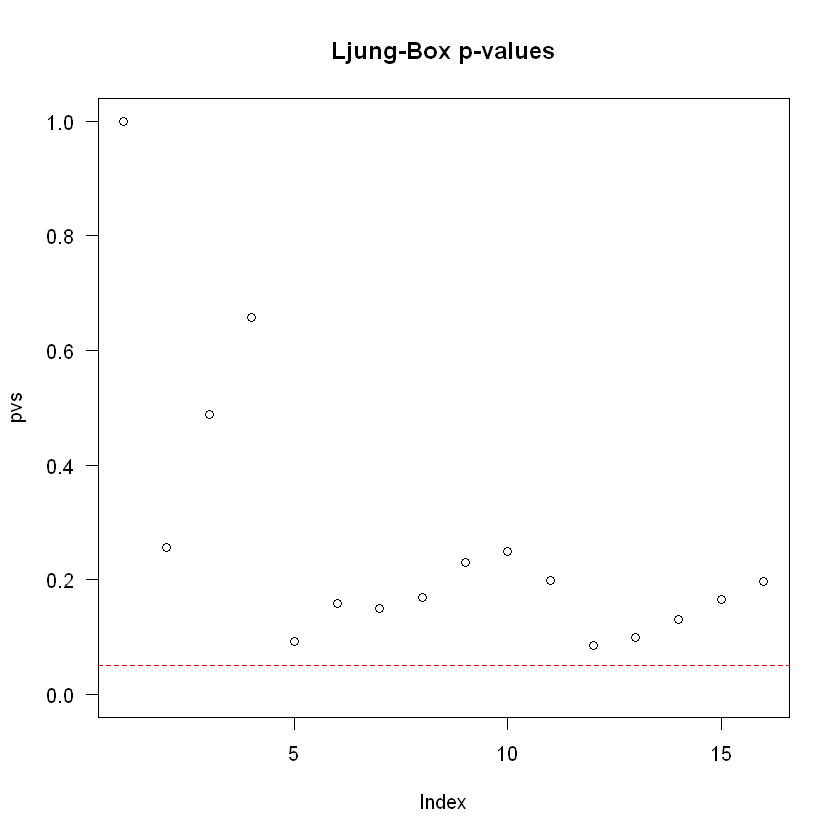

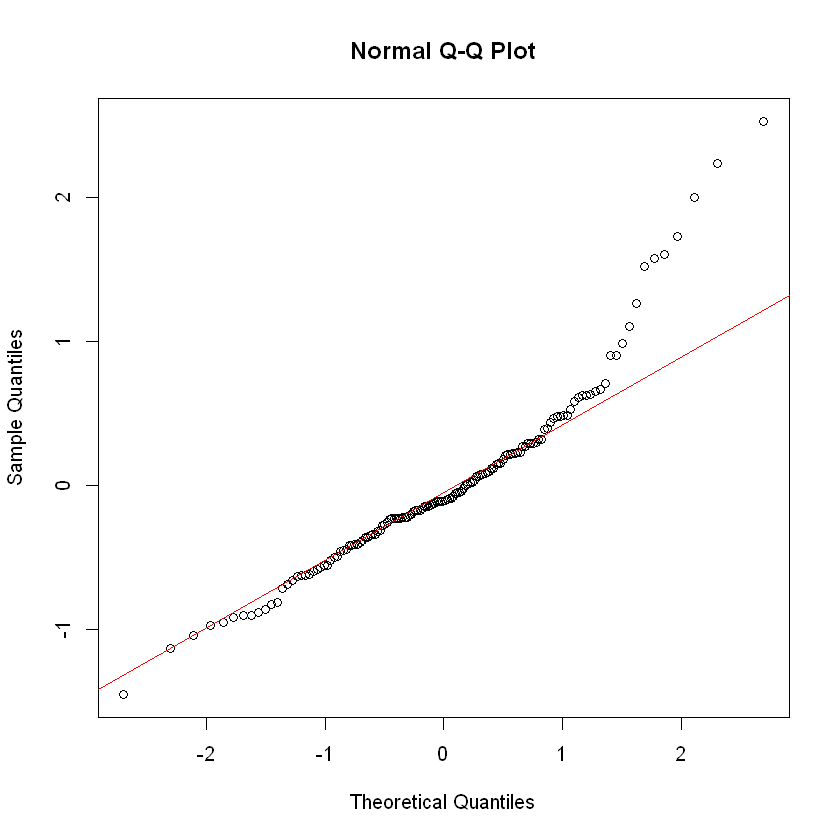

In [51]:
# let use Ljung-box to test if they are really white noise (i.e. the AR(1) is appropriate for residuals)
degree_freedom = 1  
pvs = rep(1, 16)
for(i in (degree_freedom+1):16) {
  pvs[i] = Box.test(ar1.res, lag=i, type="Ljung-Box", fitdf=degree_freedom)$p.value
}
plot(pvs, las=1, main="Ljung-Box p-values", ylim=c(0,1))
abline(h=0.05, col="red", lty=2)

# RUNS test
runs(ar1.res)

# QQ plot
qqnorm(ar1.res)     
qqline(ar1.res, col="red") 

> - From the `Runs` test, there is no evidence against independence in the residuals.
> - From the `QQ` plot, the residuals deviate from normality. Therefore, the assumption of Gaussian errors is questionable, which may affect the interpretation of statistical inference from the linear model with sinusoidal terms.
> - From the `Ljung–Box` test, all p-values are greater than `0.05`, so we fail to reject the null hypothesis of no autocorrelation. This indicates that the residuals behave like `white noise`, and supports the adequacy of the AR(1) model.

### 2. ARIMA technique

- Taking first diffrence to remove linear trend.

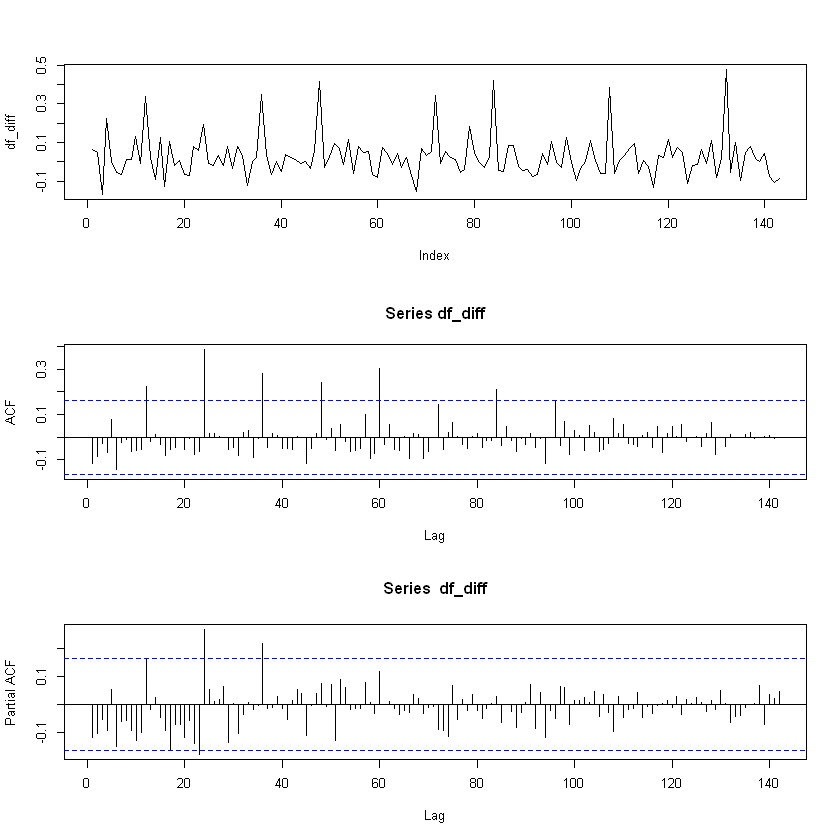

In [83]:
df_diff = diff(as.numeric(df))

par(mfrow=c(3,1))
plot(df_diff, type='l')
acf(df_diff, lag.max=143)   
pacf(df_diff, lag.max=143)
par(mfrow=c(1,1))

> - This first difference series appears to have zero mean. However, the variance doesn't seem to be constant. Also, there seems to be some kind seasonal effect still. So, there is evidence that this first difference series is not stationary because its variance is not constant through time.
> - A clear seasonality with period = `12` from the `ACF` plot. so we need to remove seasonality by diffrencing at lags 12.

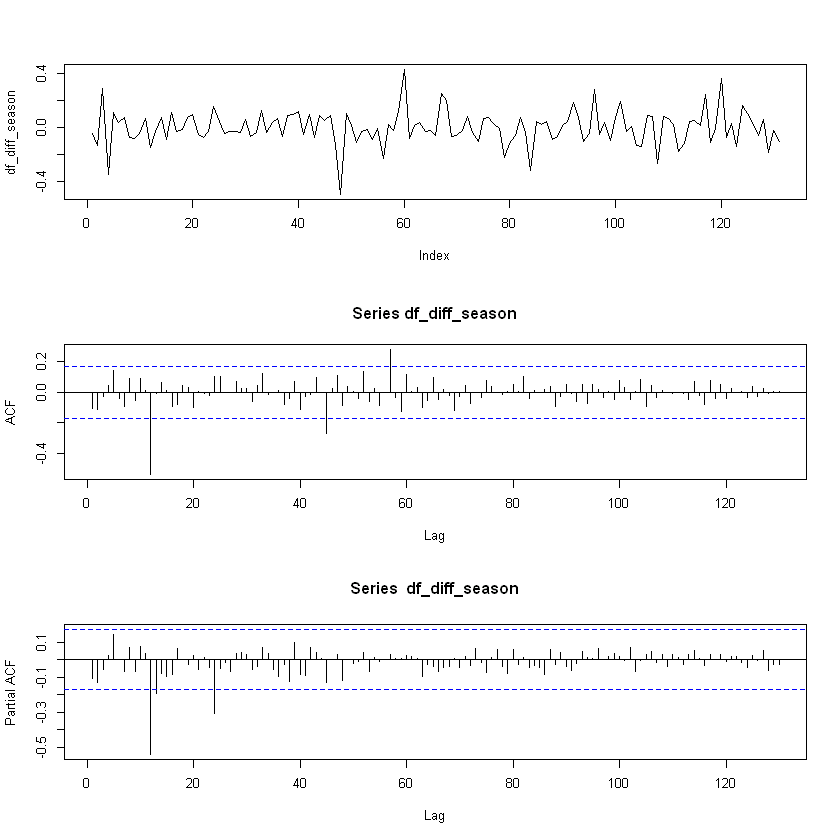

In [85]:
df_diff_season <- diff(df_diff, lag=12)  # remove yearly seasonality

par(mfrow=c(3,1))
plot(df_diff_season, type='l')
acf(df_diff_season, lag.max=143)   
pacf(df_diff_season, lag.max=143)
par(mfrow=c(1,1))

> - we can see that from plot 1 : we variance is quite stable and points are around a constant (zero) mean
> - From the ACF and PACF plots, most of the spikes lie within the confidence bounds (`±2/√n`), which suggests the absence of significant autocorrelation. However, this should be formally validated using a Ljung–Box test.

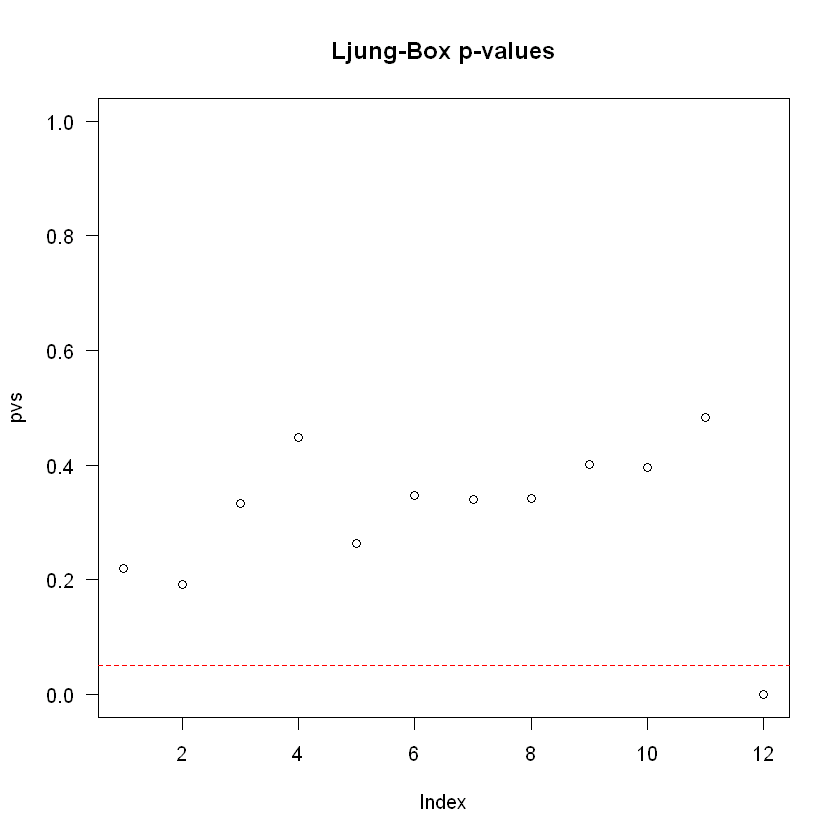

In [86]:
# let use Ljung-box to test if they are really white noise
degree_freedom = 0  
pvs = rep(1, 12)
for(i in (degree_freedom+1):12) {
  pvs[i] = Box.test(df_diff_season, lag=i, type="Ljung-Box", fitdf=degree_freedom)$p.value
}
plot(pvs, las=1, main="Ljung-Box p-values", ylim=c(0,1))
abline(h=0.05, col="red", lty=2)

> - what we did is equivalent to : `SARIMA(0,1,0)(0,1,0)12​`
> - From the `Ljung–Box` test, all p-values are greater than `0.05`, so we fail to reject the null hypothesis of no autocorrelation. This indicates that the residuals behave like `white noise`, and supports the adequacy of the SARIMA(0,1,0)(0,1,0)12​ model.

In [57]:
sarima010_010_12 = Arima(df, order=c(0,1,0), seasonal=list(order=c(0,1,0), period=12))
summary(sarima010_010_12)

Series: df 
ARIMA(0,1,0)(0,1,0)[12] 

sigma^2 = 0.01579:  log likelihood = 86.01
AIC=-170.03   AICc=-170   BIC=-167.15

Training set error measures:
                       ME      RMSE        MAE          MPE      MAPE      MASE
Training set -0.001546895 0.1198519 0.08486561 -0.007799798 0.3643869 0.2425892
                   ACF1
Training set -0.1036622

> - The model selection criteria, with `AIC = -170.03` and `BIC = -167.15`, indicate a reasonably good fit compared to alternative specifications (that i did before) and to previous modeling.

### 3. Smoothing method

- let try the non-parametric approach maybe we will get good modeling

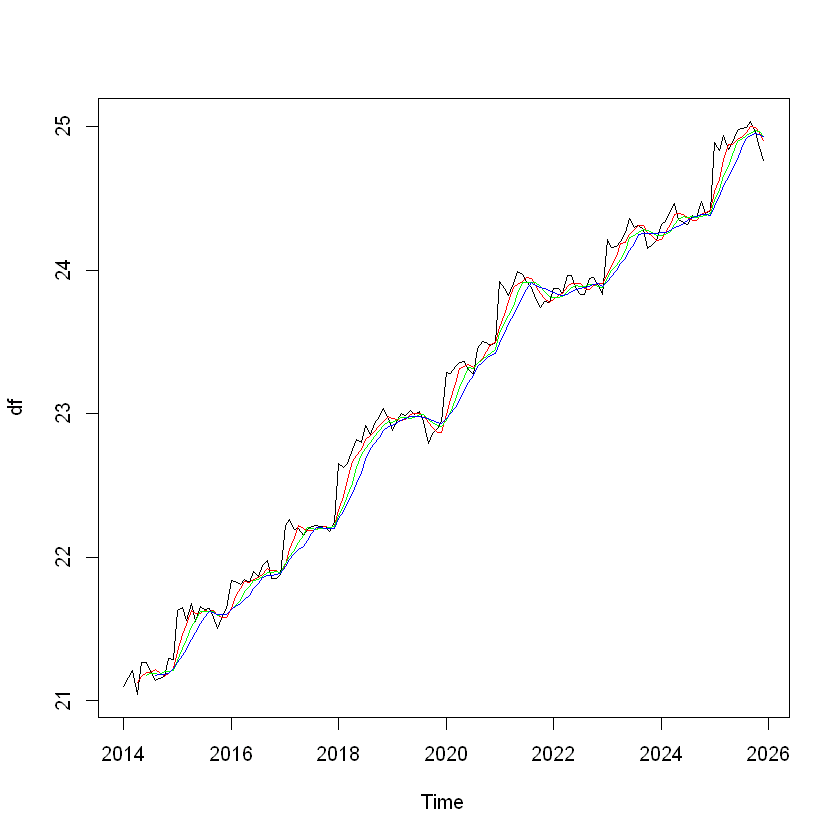

In [58]:
# using methode de lissage
plot(df)

filter1 <- stats::filter(df, rep(1/4, 4), side=1)
lines(filter1, col='red')

filter2 <- stats::filter(df, rep(1/6, 6), side=1)
lines(filter2, col='green')

filter3 <- stats::filter(df, rep(1/8, 8), side=1)
lines(filter3, col='blue')

> - it seems filter2 (i.e. avergage of 6) is suitable choice.

In [59]:
df_filterd = as.numeric(filter2)
df_filterd <- na.omit(df_filterd) 
length(df_filterd)

[1] 139

Warning message in as.numeric(df) - df_filterd:
"la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court"


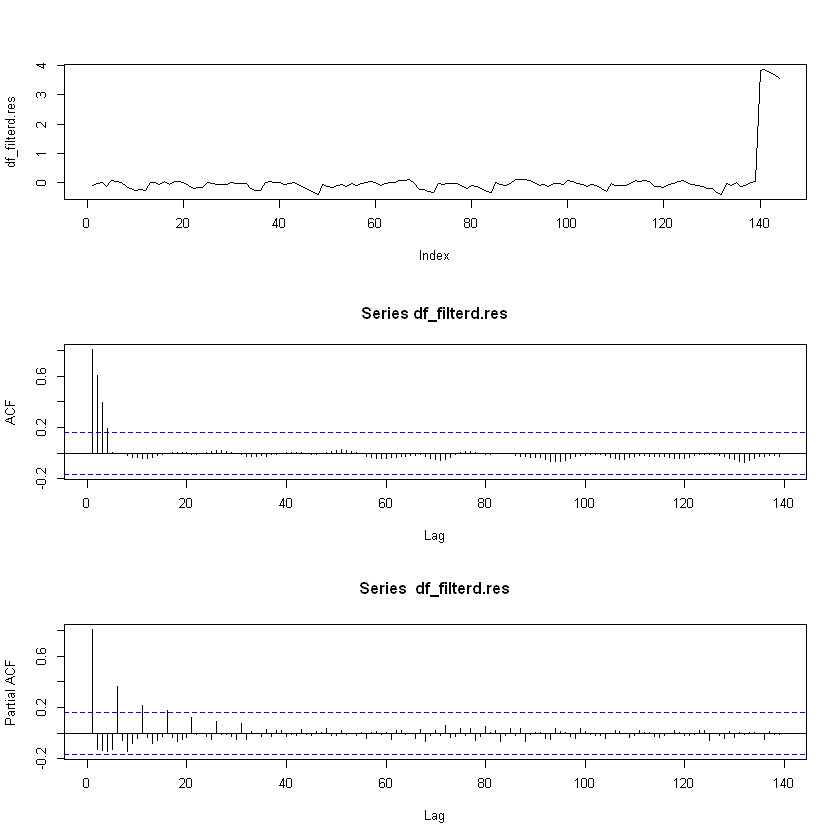

In [60]:
df_filterd.res <- as.numeric(df) - df_filterd

par(mfrow=c(3,1))
plot(df_filterd.res, type='l')
acf(df_filterd.res, lag.max = 139)
pacf(df_filterd.res, lag.max = 139)
par(mfrow=c(1,1))

> - From the ACF, we observe that autocorrelations become negligible after approximately lag `4`, suggesting that the dependence structure is short-ranged.
> - The PACF shows a gradually decaying pattern rather than a sharp cutoff, which is more consistent with an MA-type process rather than an AR process.
> - Based on the ACF/PACF behavior, the residual component can be reasonably modeled as an `MA(4)` process.

Series: df_filterd.res 
ARIMA(0,0,4) with non-zero mean 

Coefficients:
         ma1     ma2     ma3     ma4    mean
      0.9149  0.9316  0.8298  0.6391  0.0840
s.e.  0.0726  0.1097  0.1185  0.0923  0.1185

sigma^2 = 0.1152:  log likelihood = -47.73
AIC=107.46   AICc=108.07   BIC=125.28

Training set error measures:
                       ME    RMSE       MAE      MPE     MAPE    MASE
Training set 0.0004830429 0.33347 0.1268709 40.79941 720.4481 1.31161
                   ACF1
Training set 0.05003763

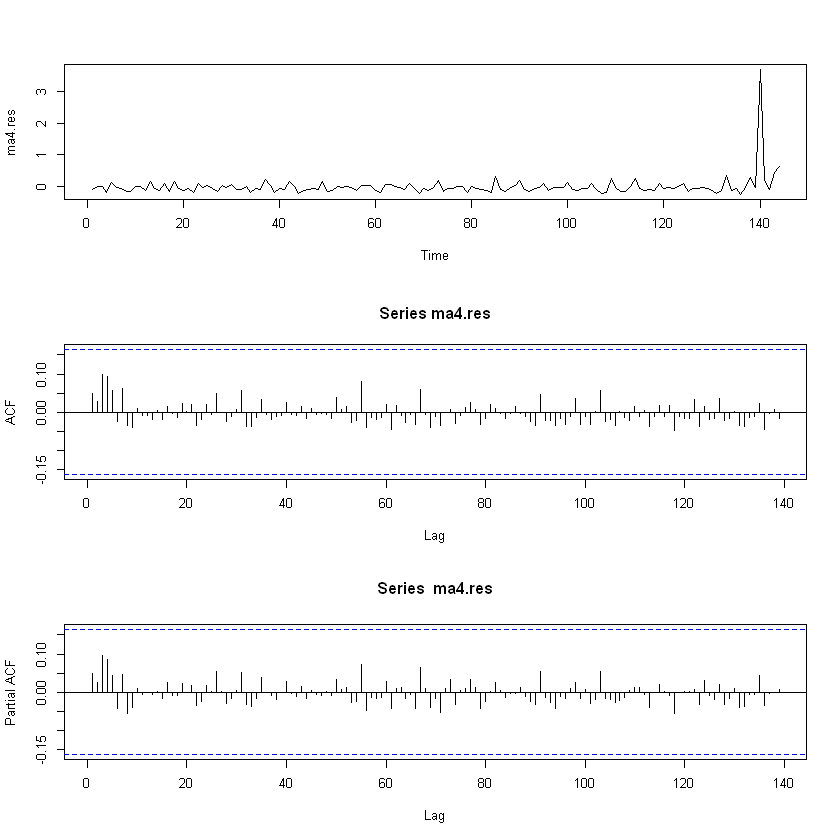

In [87]:
ma4 = Arima(df_filterd.res, order=c(0,0,4))
summary(ma4)

ma4.res = residuals(ma4)

par(mfrow=c(3,1))
plot(ma4.res, type='l')
acf(ma4.res, lag.max = 139)
pacf(ma4.res, lag.max = 139)
par(mfrow=c(1,1))

> - we can see that from plot 1 : variance is quite stable and points are around a constant (zero) mean (weired at 140!)
> - The model selection criteria, with `AIC = 107.46` and `BIC = 125.28`, indicate a reasonably good fit compared to alternative specifications (that i did before) but quite not that good as previous modeling.
> - From the ACF and PACF plots, all of the spikes lie within the confidence bounds (`±2/√n`), which suggests the absence of significant autocorrelation. However, this should be formally validated using a Ljung–Box test.

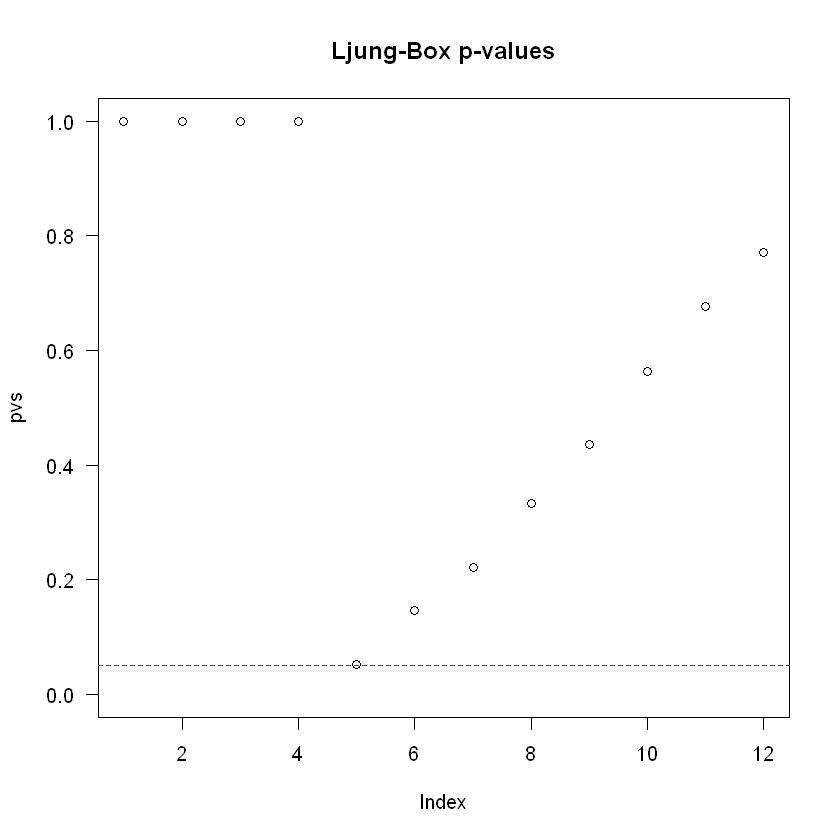

In [ ]:
# let use Ljung-box to test if they are really white noise 
degree_freedom = 4
pvs = rep(1, 12)
for(i in (degree_freedom+1):12) {
  pvs[i] = Box.test(ma4.res, lag=i, type="Ljung-Box", fitdf=degree_freedom)$p.value
}
plot(pvs, las=1, main="Ljung-Box p-values", ylim=c(0,1))
abline(h=0.05, col="red", lty=2)

> - From the `Ljung–Box` test, all p-values are greater than `0.05`, so we fail to reject the null hypothesis of no autocorrelation. This indicates that the residuals behave like `white noise`, and supports the adequacy of the `MA(4)` model and the smoothing filter.

## Forecasting & Discussion 

In [91]:
H = 48 # Forecasting for next 3 years
lambda <- 0.2 # Box-Cox lambda

y_ts <- ts(y_original, start = c(2014,1), frequency = 12)
t_future <- (length(df)+1):(length(df)+H)
time_future <- time(y_ts)[length(y_ts)] + (1:H)/frequency(y_ts)

### Forecasting by the 1st model

$$
Y_t = u_t + X_t
$$

where:

$$
u_t = \beta_0 + \beta_1 t + \beta_2 \cos\left(\frac{2\pi t}{m}\right) + \beta_3 \sin\left(\frac{2\pi t}{m}\right)
$$

$$
X_t = \phi X_{t-1} + \varepsilon_t
$$

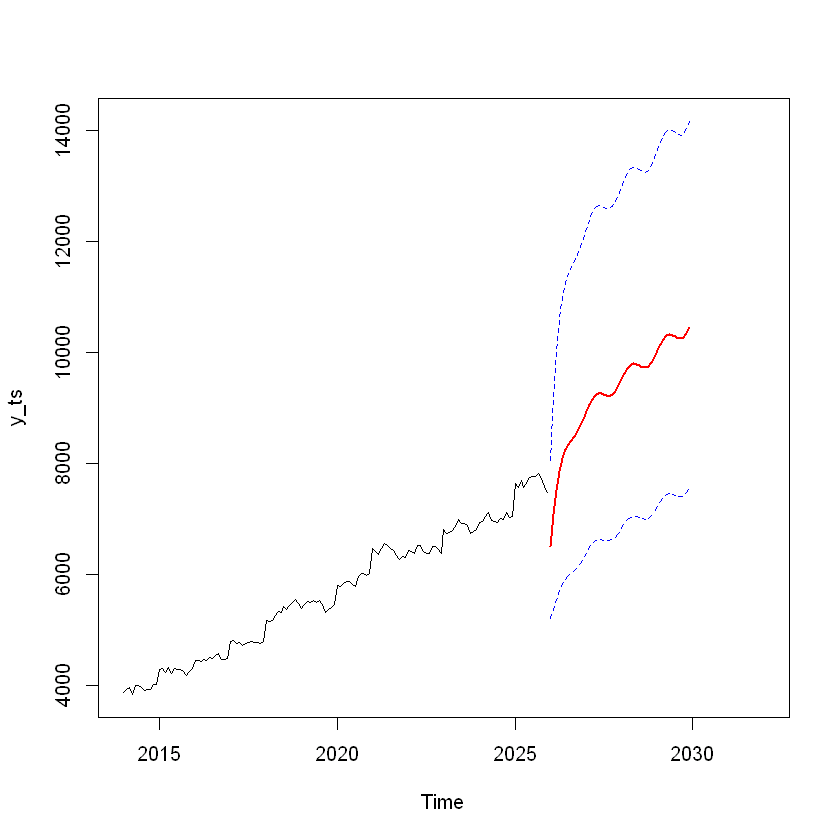

In [92]:
#  Forecast AR(1) residuals
res_forecast <- forecast(ar1, h = H)

#  Forecast deterministic part (trend + seasonality)
det_part <- predict(full_model, newdata = data.frame(t = t_future))

#  Total forecast on Box-Cox scale
Z_hat <- det_part + res_forecast$mean

# Linear model variance
det_pred_var <- predict(full_model, newdata = data.frame(t=t_future), se.fit=TRUE)$se.fit^2
# AR(1) forecast variance
phi <- coef(ar1)[1]
sigma2 <- ar1$sigma2
l <- 1:H
ar1_var <- sigma2 * (1 - phi^(2*l)) / (1 - phi^2)

# Total forecast variance
total_var <- det_pred_var + ar1_var

#  Back-transform 
Y_hat <- InvBoxCox(Z_hat + total_var/2, lambda)

# Prediction intervals
Y_lower <- InvBoxCox(Z_hat - 1.96*sqrt(total_var) + total_var/2, lambda)
Y_upper <- InvBoxCox(Z_hat + 1.96*sqrt(total_var) + total_var/2, lambda)

y_min <- min(c(y_ts, Y_lower))
y_max <- max(c(y_ts, Y_upper))

# plot
plot(y_ts,ylim = c(y_min, y_max),xlim = c(start(y_ts)[1], end(y_ts)[1] + H/frequency(y_ts) + 3))
lines(time_future, Y_hat, col = "red", lwd = 2)     
lines(time_future, Y_lower, col = "blue", lty = 2)     
lines(time_future, Y_upper, col = "blue", lty = 2)    

> - The forecast appears to capture the overall downward movement from the last observed values, which is reasonable given the presence of yearly seasonality in the data. However, the predicted values seem systematically too low, suggesting a possible underestimation bias.
> - The model also captures the linear trend component perfectly, but the seasonal pattern is not well preserved in the long-term forecasts. In particular, future seasonal fluctuations appear significantly dampened compared to historical patterns, indicating that the seasonal structure is not fully maintained out-of-sample.
> - Additionally, the prediction intervals become narrower over time. While some reduction in uncertainty is expected due to model structure, the strong shrinking of the confidence bands may be unrealistic and suggests that long-term variability is being underestimated.

#### Forecasting by 2nd model

$$
(1 - B)(1 - B^{12}) Y_t = \varepsilon_t
$$

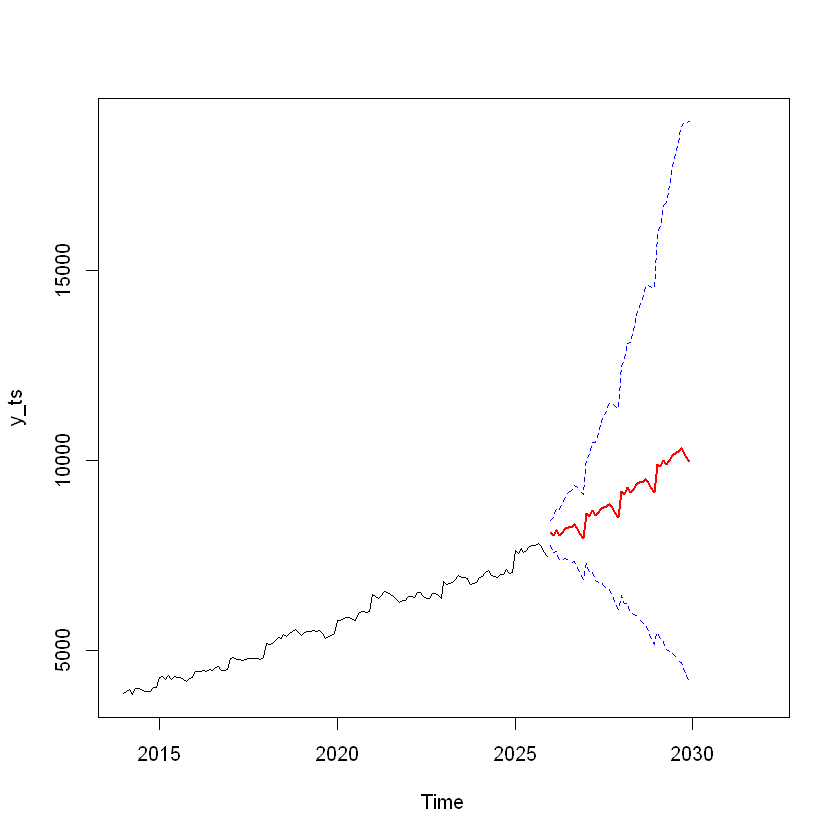

In [89]:
# Forecast SARIMA with Box-Cox back-transform
sarima_fc <- forecast(sarima010_010_12, h = H, lambda = 0.2, biasadj = TRUE)

# Convert forecast and intervals to ts
Y_hat_ts <- ts(sarima_fc$mean, start=end(y_ts) + c(0,1), frequency=frequency(y_ts))
Y_lower_ts <- ts(sarima_fc$lower[,2], start=end(y_ts) + c(0,1), frequency=frequency(y_ts))
Y_upper_ts <- ts(sarima_fc$upper[,2], start=end(y_ts) + c(0,1), frequency=frequency(y_ts))

y_min <- min(c(y_ts, Y_lower_ts))
y_max <- max(c(y_ts, Y_upper_ts))

# Plot
plot(y_ts,ylim=c(y_min, y_max),xlim=c(start(y_ts)[1], end(y_ts)[1] + H/frequency(y_ts) + 3))
lines(Y_hat_ts, col="red", lwd=2)
lines(Y_lower_ts, col="blue", lty=2)
lines(Y_upper_ts, col="blue", lty=2)

> - For the second modeling strategy using `SARIMA(0,1,0)(0,1,0)[12]`, the forecast shows improved behavior in capturing both the linear trend and the seasonal structure. The prediction intervals also appear more realistic compared to the first approach.
> - The model successfully continues the observed seasonal pattern, particularly the yearly cycle, and maintains consistency with the historical seasonal behavior. The forecasts for the following year reflect this seasonal repetition in a more coherent way.
> - However, as the forecast horizon increases, the confidence intervals become considerably wider, indicating growing uncertainty over time. This behavior is expected in integrated seasonal models, but it is more pronounced compared to the first modeling strategy.

#### Forecasting by 3rd model

$$
Y_t = T_t + X_t
$$
where:
$$
T_t = \frac{1}{6} \left( Y_{t-1} + Y_{t-2} + Y_{t-3} + Y_{t-4} + Y_{t-5} + Y_{t-6} \right)
$$
$$
X_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \theta_3 \varepsilon_{t-3} + \theta_4 \varepsilon_{t-4}
$$

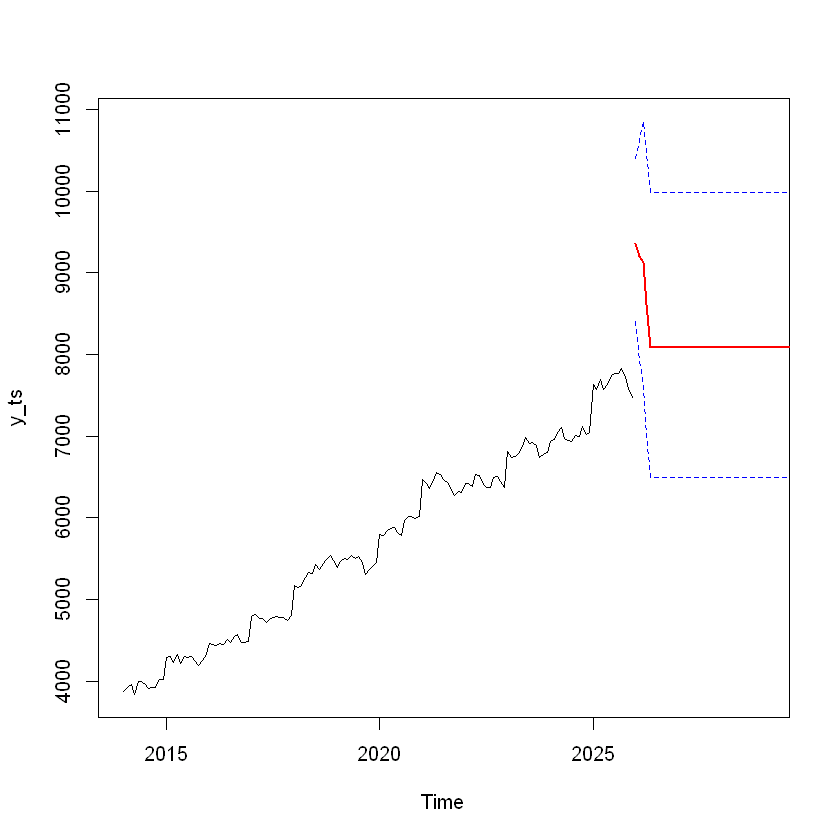

In [93]:
#  Forecast MA(4) residuals
res_forecast <- forecast(ma4, h=H)

#  Forecast trend 
# Use last available filtered value
last_trend <- tail(df_filterd, 1)

trend_future <- rep(last_trend, H)

#  Total forecast on Box-Cox scale
Z_hat <- trend_future + res_forecast$mean

#  Variance 
se_hat <- (res_forecast$upper[,2] - res_forecast$mean) / 1.96
total_var <- se_hat^2

#  Back-transform of Box-Cox
Y_hat <- InvBoxCox(Z_hat + total_var/2, lambda)

Y_lower <- InvBoxCox(Z_hat - 1.96*sqrt(total_var) + total_var/2, lambda)
Y_upper <- InvBoxCox(Z_hat + 1.96*sqrt(total_var) + total_var/2, lambda)

time_future <- time(y_ts)[length(y_ts)] + (1:H)/frequency(y_ts)

# plot
y_min <- min(c(y_ts, Y_lower))
y_max <- max(c(y_ts, Y_upper))

plot(y_ts,ylim=c(y_min, y_max),xlim=c(start(y_ts)[1], end(y_ts)[1] + H/frequency(y_ts)))
lines(time_future, Y_hat, col="red", lwd=2)
lines(time_future, Y_lower, col="blue", lty=2)
lines(time_future, Y_upper, col="blue", lty=2)

> - This approach (smoothing-based model) appears to perform the worst among the considered methods. The forecast starts from an unrealistically high value and then rapidly decreases toward a horizontal mean level, which is not consistent with the historical pattern of the series.
> - The model fails to capture both the underlying linear trend and the seasonal structure present in the data. As a result, the long-term forecasts collapse toward a smoothed constant level, losing the dynamic behavior observed in the original series.


### 5. Discussion

> This project explored <b>multiple modeling approaches</b> for electricity consumption.

>we can see the best modeling for that data is the 2nd model : `SARIMA(0,1,0)(0,1,0)[12]` it captures very well the patterns (trend + >seasonality) with reasonable forecasting values unlike the 1st model.

###  Key challenges:
> - <span style=""><b>Handling seasonality</b></span>  
> - <span style=""><b>Achieving stationarity</b></span>  
> - <span style=""><b>Model selection</b></span>  

>  Future work:
> - Explore **advanced models**  
> - Incorporate **additional data sources**  